# Pulsed Qubit Spectroscopy

This notebook shows you how to perform a qubit spectroscopy experiment. You'll find the resonance frequency of the qubit by measuring the change in resonator transmission when sweeping the frequency of a qubit excitation pulse.

## 0. LabOne Q Imports

You'll begin by importing `laboneq.simple` and some extra helper functions to run the examples. 

In [1]:
import time
from pathlib import Path

# Helpers:
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)

# LabOne Q:
from laboneq.simple import *

## 1. Device Setup

Below, you'll create a device setup and choose to run this notebook in emulated mode or directly on the control hardware, by specifying `use_emulation = True/False` respectively.

If you run on your hardware, you need to generate a device setup first, please have a look at our [device setup tutorial](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/tutorials/00_device_setup.html) for how to do this in general.
Here, we use a helper functions to generate the device setup and a set up qubit objects with pre-defined parameters. 

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 6

# generate the device setup and the qubit objects using a helper function
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_channels": 8,
            "options": None,
        }
    ],
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    include_flux_lines=True,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_tunable_qubit_setup",
)

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to a session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.26 14:02:03.923] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/tune-up/laboneq_output/log
[2026.06.26 14:02:03.925] INFO    VERSION: laboneq 26.4.0
[2026.06.26 14:02:03.926] INFO    Connecting to data server at localhost:8004
[2026.06.26 14:02:03.927] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.26 14:02:03.928] INFO    Configuring the device setup
[2026.06.26 14:02:03.955] INFO    The device setup is configured


## 2. Experiment Parameters

Now you'll define the frequency sweep parameters and pulse to use in your experiment.

In [4]:
# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4

# pulse parameters and definitions
envelope_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6


def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse


drive_length = 1e-6


def create_drive_spec_pulse(qubit, length=drive_length, amplitude=0.9):
    pulse = pulse_library.const(
        uid=f"drive_spec_pulse_{qubit}", length=length, amplitude=amplitude
    )
    return pulse


def create_drive_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"drive_freq_{qubit}", start=start_freq, stop=stop_freq, count=num_points
    )

## 3. Experiment Definition

To perform qubit spectroscopy, you'll create a function which generates an [experiment](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/05_experiment/concepts/index.html). In this experiment, you'll pass a frequency sweep parameter as an argument to the [sweep section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/04_averaging_sweeping.html#parameter-sweeps). Within the sweep section, you'll create another [section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/index.html) containing a `play` command to drive the qubit and an `play` and `acquire` commands to perform readout. Within the real-time acquisition section, you'll set use `INTEGRATION` as your acquisition type.

In [5]:
# function that returns a qubit spectroscopy experiment- accepts frequency sweep range as parameter


def qubit_spectroscopy(freq_sweep, drive_pulse, readout_pulse):
    # Create qubit spectroscopy Experiment - uses qubit drive, readout drive and data acquisition lines
    exp_qspec = Experiment(
        uid="Qubit Spectroscopy",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    # inner loop - real-time averaging - QA in integration mode
    with exp_qspec.acquire_loop_rt(
        uid="freq_shots",
        count=2**num_averages,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        with exp_qspec.sweep(uid="qfreq_sweep", parameter=freq_sweep):
            # qubit drive
            with exp_qspec.section(uid="qubit_excitation"):
                exp_qspec.play(signal="drive", pulse=drive_pulse)
            with exp_qspec.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                exp_qspec.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_qspec.acquire(
                    signal="acquire",
                    handle="qb_spec",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_qspec.section(uid="relax", length=1e-6):
                exp_qspec.reserve(signal="measure")

    return exp_qspec

### 3.1 Signal Map

Before running the experiment, you'll define and set the mapping between the experimental and logical lines.

In [6]:
# frequency range of spectroscopy scan - defined around expected qubit frequency as defined in qubit parameters
qspec_range = 100e6
# how many frequency points to measure
qspec_num = 1001
freq_sweep_q0 = create_drive_freq_sweep("q0", -qspec_range, qspec_range, qspec_num)

# experiment signal calibration for qubit 0
exp_calibration_q0 = Calibration()
exp_calibration_q0["drive"] = SignalCalibration(
    oscillator=Oscillator(
        frequency=freq_sweep_q0,
        modulation_type=ModulationType.HARDWARE,
    ),
)


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "drive"
        ],
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


# define experiment with frequency sweep for qubit 0
drive_pulse = create_drive_spec_pulse("q0")
readout_pulse = create_readout_pulse("q0", sigma=0.2, width=1e-6)

exp_qspec = qubit_spectroscopy(freq_sweep_q0, drive_pulse, readout_pulse)

# apply calibration and signal map for qubit 0
exp_qspec.set_calibration(exp_calibration_q0)
exp_qspec.set_signal_map(signal_map_default("q0"))

### 3.2 Compile, Generate Pulse Sheet, and Plot Simulated Signals

Now, you'll compile the experiment and generate a pulse sheet.

In [7]:
# compile the experiment on the open instrument session
compiled_qspec = session.compile(exp_qspec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Qubit_Spectroscopy", compiled_qspec)

[2026.06.26 14:02:03.980] INFO    Starting LabOne Q Compiler run...
[2026.06.26 14:02:03.982] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.26 14:02:03.982] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.26 14:02:03.986] INFO    Schedule completed. [0.004 s]
[2026.06.26 14:02:04.001] INFO    Code generation completed for all AWGs. [0.014 s]
[2026.06.26 14:02:04.002] INFO    Completed compilation step 1 of 1. [0.020 s]
[2026.06.26 14:02:04.005] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.26 14:02:04.006] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.26 14:02:04.006] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.26 14:02:04.006] INFO      shfqc_0        0         10            0           1      8000  
[2026.06.26 14:02:04.006] INFO      shfqc_0_sg     0         23            2           1 

/Users/khatran/Desktop/pico-thermometry/tune-up/Pulse_Sheets/Qubit_Spectroscopy_2026-06-26-14-02-04.html

In addition to creating a pulse sheet to inspect the timing of pulses, you can simulate physical output of the channels.

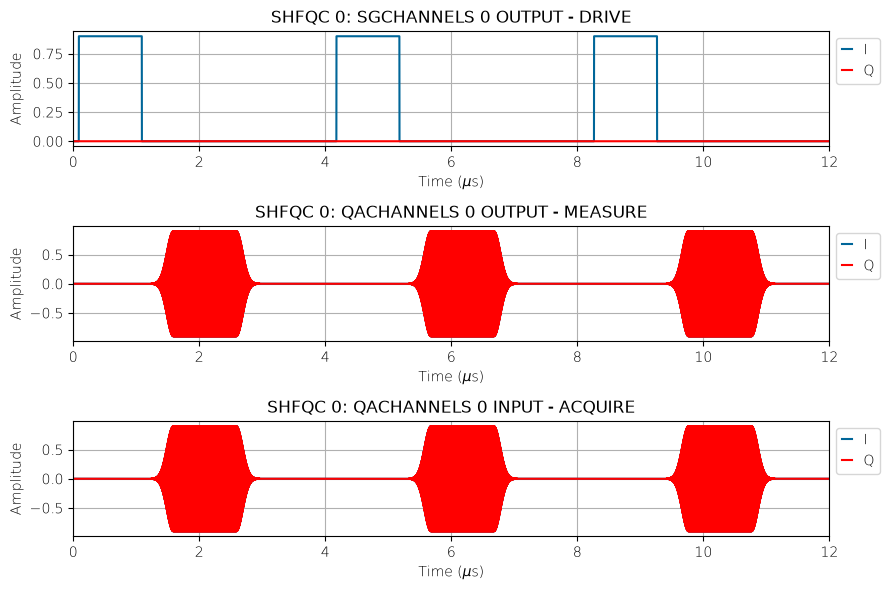

In [8]:
plot_simulation(compiled_qspec, start_time=0, length=12e-6)

### 3.3 Run, Save, and Plot Results

Finally, you'll run the experiment, save, and plot the results.

In [9]:
# run the compiled experiemnt
qspec_results = session.run(compiled_qspec)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(qspec_results, f"Results/{timestamp}_qspec_results.json")
print(f"File saved as Results/{timestamp}_qspec_results.json")

[2026.06.26 14:02:04.499] INFO    Starting near-time execution...
[2026.06.26 14:02:04.515] INFO    Finished near-time execution.
File saved as Results/20260626T140204_qspec_results.json


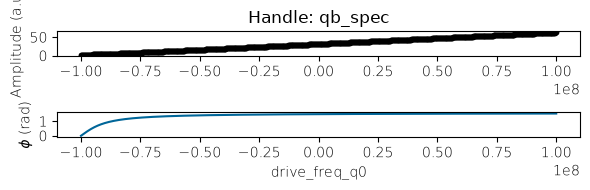

In [10]:
plot_results(qspec_results, phase=True)